# 1. Environment Setup & Exact Data Splitting
**Purpose:**
* Initialize the computational environment, configure deterministic seeds, and define structural paths.
* Migrate and cleanly split the original dataset into independent Train, Valid, and Test sets to prevent data leakage and maintain the integrity of the validation split.

In [1]:
# ==========================================
# 1. Environment Setup & Exact Data Splitting
# ==========================================
!pip install ultralytics==8.4.114 albumentations==2.0.8

import os
import cv2
import yaml
import torch
import random
import shutil
import collections
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import albumentations as A
from albumentations.core.transforms_interface import ImageOnlyTransform
from ultralytics import YOLO
import ultralytics.data.augment as aug

# Deterministic Seed Configuration
SEED = 2102
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Path Configurations
DATASET_PATH = Path("/kaggle/input/datasets/hongphngh/dataset")
WORKING_DIR = Path("/kaggle/working")
LOCAL_DATA_DIR = WORKING_DIR / "dataset_local"

if LOCAL_DATA_DIR.exists():
    shutil.rmtree(LOCAL_DATA_DIR)

print("Migrating dataset with exact original splitting...")
for split in ['train', 'valid', 'test']:
    (LOCAL_DATA_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (LOCAL_DATA_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)
    
    img_dir = DATASET_PATH / split / 'images'
    lbl_dir = DATASET_PATH / split / 'labels'
    
    if img_dir.exists():
        for img_path in img_dir.glob('*.*'):
            lbl_path = lbl_dir / f"{img_path.stem}.txt"
            if lbl_path.exists():
                shutil.copy2(img_path, LOCAL_DATA_DIR / split / 'images' / img_path.name)
                shutil.copy2(lbl_path, LOCAL_DATA_DIR / split / 'labels' / lbl_path.name)

print("Dataset migration complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Migrating dataset with exact original splitting...
Dataset migration complete.


# 2. Offline BBox-Aware Augmentation for Rare Classes
**Purpose:**
* Dynamically parse the dataset to identify underrepresented minority classes and known difficult classes.
* Execute offline, bounding-box-aware spatial and pixel-level augmentations to generate genuine synthetic training samples without violating format boundaries.

In [2]:
# ==========================================
# 2. Offline BBox-Aware Augmentation for Rare Classes
# ==========================================
print("\n--- Executing BBox-Aware Augmentation for Rare Classes ---")

train_img_dir = LOCAL_DATA_DIR / 'train' / 'images'
train_lbl_dir = LOCAL_DATA_DIR / 'train' / 'labels'
original_yaml_path = DATASET_PATH / "data.yaml"

with open(original_yaml_path, 'r') as f:
    yaml_data = yaml.safe_load(f)
    
class_name_to_id = {v: k for k, v in yaml_data['names'].items()} if isinstance(yaml_data['names'], dict) else {name: i for i, name in enumerate(yaml_data['names'])}

# Classes needing explicit targeted improvements
hard_class_names = [
    '133-het-cam-vuot', '134-het-han-che-toc-do-toi-da', 
    '423a-duong-nguoi-di-bo-sang-ngang-1', '103b-cam-oto-re-phai',
    '124b-cam-oto-quay-dau-xe', '301a-cac-xe-chi-duoc-di-thang'
]
hard_class_ids = {class_name_to_id[name] for name in hard_class_names if name in class_name_to_id}

class_counts = collections.Counter()
img_to_classes = collections.defaultdict(list)

for lbl_file in train_lbl_dir.glob('*.txt'):
    with open(lbl_file, 'r') as f:
        classes_in_file = [int(line.strip().split()[0]) for line in f if line.strip()]
        for c in classes_in_file: class_counts[c] += 1
        img_to_classes[lbl_file.stem] = classes_in_file

# Threshold for defining a rare class
rare_classes = {c for c, count in class_counts.items() if count < 50}
rare_classes.update(hard_class_ids)

# BBox-aware Transformation Pipeline
offline_aug_pipeline = A.Compose([
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=10, p=0.7, border_mode=cv2.BORDER_REPLICATE),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3))

augmented_samples_count = 0
multiply_factor = 3

for stem, classes in img_to_classes.items():
    if any(c in rare_classes for c in classes):
        src_img_path = next(train_img_dir.glob(f"{stem}.*"))
        src_lbl_path = train_lbl_dir / f"{stem}.txt"
        
        image = cv2.imread(str(src_img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        bboxes, class_labels = [], []
        with open(src_lbl_path, 'r') as f:
            for line in f:
                c, x, y, w, h = map(float, line.strip().split())
                # Clamp boundaries tightly to prevent Albumentations errors
                x, y = np.clip(x, 0.001, 0.999), np.clip(y, 0.001, 0.999)
                w = np.clip(w, 0.001, min((1-x)*2, x*2, 0.999))
                h = np.clip(h, 0.001, min((1-y)*2, y*2, 0.999))
                bboxes.append([x, y, w, h])
                class_labels.append(int(c))
                
        for i in range(multiply_factor):
            try:
                augmented = offline_aug_pipeline(image=image, bboxes=bboxes, class_labels=class_labels)
                new_stem = f"{stem}_augmented_rare_{i}"
                aug_img_bgr = cv2.cvtColor(augmented['image'], cv2.COLOR_RGB2BGR)
                
                cv2.imwrite(str(train_img_dir / f"{new_stem}.jpg"), aug_img_bgr)
                with open(train_lbl_dir / f"{new_stem}.txt", 'w') as f:
                    for bbox, cls_id in zip(augmented['bboxes'], augmented['class_labels']):
                        f.write(f"{cls_id} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
                augmented_samples_count += 1
            except Exception as e:
                print(f"Skipping {new_stem}: {e}")

print(f"Successfully generated {augmented_samples_count} genuine augmented samples for rare classes.")


--- Executing BBox-Aware Augmentation for Rare Classes ---


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Successfully generated 2289 genuine augmented samples for rare classes.


# 3. Evaluation Augmentations (+15% HARDER)
**Purpose:**
* Formulate aggressive degradation pipelines (Night, Fog, Rain, Blur) representing +15% harder environmental conditions.
* Generate and store extreme synthetic weather datasets specifically for stress-testing the model's domain robustness.

In [3]:
# ==========================================
# 3. Evaluation Augmentations (+15% HARDER)
# ==========================================
class HarderAdaptiveNight(ImageOnlyTransform):
    def __init__(self, p=1.0):
        super().__init__(p=p)
        self.bright_transform = A.Compose([
            A.RandomBrightnessContrast(brightness_limit=(-0.40, -0.25), contrast_limit=(-0.05, 0.05), p=1.0),
            A.HueSaturationValue(sat_shift_limit=(-50, -30), p=1.0) 
        ])
        self.dark_transform = A.Compose([A.HueSaturationValue(sat_shift_limit=(-50, -30), p=1.0)])
        
    def apply(self, img, **params):
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
        return self.bright_transform(image=img)['image'] if np.mean(gray_img) > 105 else self.dark_transform(image=img)['image']

class FastFog(ImageOnlyTransform):
    def __init__(self, intensity_range=(0.2, 0.5), base_thickness=0.45, p=0.20):
        super().__init__(p=p)
        self.intensity_range = intensity_range; self.base_thickness = base_thickness
    def apply(self, img, **params):
        h, w = img.shape[:2]; inten = np.random.uniform(*self.intensity_range)
        mask = cv2.resize(np.random.rand(max(h//16,2), max(w//16,2)).astype(np.float32), (w, h), interpolation=cv2.INTER_CUBIC)
        mask = cv2.GaussianBlur(mask, (0, 0), sigmaX=w/16)
        alpha = np.clip(self.base_thickness + ((mask - mask.min()) / (np.ptp(mask) + 1e-6)) * inten, 0, 1)[..., None]
        return (img * (1 - alpha) + np.full_like(img, 215, dtype=np.uint8) * alpha).astype(np.uint8)

test_pipelines = {
    'night': A.Compose([HarderAdaptiveNight(p=1.0)]),
    'fog': A.Compose([FastFog(intensity_range=(0.25, 0.50), base_thickness=0.50, p=1.0)]), 
    'rain': A.Compose([A.RandomRain(slant_range=(-15, 15), drop_length=15, drop_width=2, blur_value=2, p=1.0)]),
    'blur': A.Compose([A.MotionBlur(blur_limit=(5, 9), p=1.0)]) 
}

TEST_DIR = LOCAL_DATA_DIR / 'test' / 'images'
TEST_EFFECT_DIRS = {}

for effect in test_pipelines.keys():
    effect_root = WORKING_DIR / "test_weather_effects" / f"test_{effect}"
    (effect_root / "images").mkdir(parents=True, exist_ok=True)
    (effect_root / "labels").mkdir(parents=True, exist_ok=True)
    TEST_EFFECT_DIRS[effect] = {"images": effect_root / "images", "labels": effect_root / "labels"}

print("\n--- Generating +15% Harder Weather Effects for Test Set ---")
for img_path in TEST_DIR.glob('*.*'):
    image = cv2.imread(str(img_path))
    if image is None: continue
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_label = LOCAL_DATA_DIR / 'test' / 'labels' / f"{img_path.stem}.txt"
    
    for effect, pipeline in test_pipelines.items():
        aug_image_bgr = cv2.cvtColor(pipeline(image=image_rgb)['image'], cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(TEST_EFFECT_DIRS[effect]["images"] / img_path.name), aug_image_bgr)
        if original_label.exists(): shutil.copy2(original_label, TEST_EFFECT_DIRS[effect]["labels"] / f"{img_path.stem}.txt")


--- Generating +15% Harder Weather Effects for Test Set ---


# 4. Ultralytics Monkey-Patching & Model Training
**Purpose:**
* Inject a custom `A.OneOf` weather selector into the Ultralytics augmentation pipeline to ensure realistic conditions and prevent unrealistic effect stacking (overlapping augmentations).
* Execute YOLO11n training utilizing high-resolution constraints (imgsz=768) to maximize feature retention for small objects like traffic signs.

In [4]:
# ==========================================
# 4. Ultralytics Monkey-Patching & Model Training
# ==========================================
import time
import warnings

# Use A.OneOf to ensure NO overlapping weather effects on a single image.
# 60% chance to have a weather effect (and only ONE of them), 40% chance of staying Clean.
class AdaptiveNightTrain(HarderAdaptiveNight):
    def __init__(self, p=1.0):
        super().__init__(p=p)

train_online_pipeline = A.Compose([
    A.OneOf([
        AdaptiveNightTrain(p=1.0),
        FastFog(intensity_range=(0.15, 0.4), base_thickness=0.45, p=1.0),
        A.RandomRain(slant_range=(-10, 10), drop_length=12, drop_width=1, blur_value=1, p=1.0),
        A.MotionBlur(blur_limit=(3, 7), p=1.0)
    ], p=0.6)
])

OldAlbumentations = aug.Albumentations

class WeatherAlbumentations(OldAlbumentations):
    def __init__(self, p=1.0, **kwargs):
        super().__init__(p=p, **kwargs)
        self.weather_transform = train_online_pipeline
        
    def __call__(self, labels):
        im = labels['img']
        labels['img'] = self.weather_transform(image=im)['image']
        return super().__call__(labels)

aug.Albumentations = WeatherAlbumentations

train_yaml_path = WORKING_DIR / "traffic_sign_train.yaml"

with open(original_yaml_path, 'r') as f:
    yaml_content = yaml.safe_load(f)

yaml_content['path'] = str(LOCAL_DATA_DIR)
yaml_content['train'] = 'train/images'
yaml_content['val'] = 'valid/images'
yaml_content['test'] = 'test/images'

with open(train_yaml_path, 'w') as f:
    yaml.dump(yaml_content, f)

print("INITIALIZING YOLO11N FOR TRAINING (High-Res 768px)...")
model = YOLO("yolo11n.pt")

results = model.train(
    data=str(train_yaml_path),
    epochs=250,
    batch=64,
    imgsz=768,
    optimizer="AdamW",
    lr0=0.0005,
    lrf=0.01,
    patience=40,
    fliplr=0.0,
    plots=True,
    seed=SEED,
    save_period=20,
    cache='disk', 
    project=str(WORKING_DIR / "runs"),
    name="traffic_sign_yolo11n",
    exist_ok=True
)

print(f"TRAINING COMPLETED. BEST WEIGHTS RETAINED AT: {model.trainer.best}")

INITIALIZING YOLO11N FOR TRAINING (High-Res 768px)...
New https://pypi.org/project/ultralytics/8.4.117 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=disk, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/traffic_sign_train.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=250, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0

# 5. Per-Class Threshold Optimization
**Purpose:**
* Algorithmically discover the optimal confidence threshold to maximize the F1 metric on a per-class basis using the independent validation set.
* Enforce a Statistical Significance Rule (MIN_INSTANCES_FOR_THRESHOLD = 15) to prevent noisy overfitting on extremely rare signs.

In [5]:
# ==========================================
# 5. Per-Class Threshold Optimization (Using Validation Set)
# ==========================================
best_weights_path = WORKING_DIR / "runs" / "traffic_sign_yolo11n" / "weights" / "best.pt"
best_model = YOLO(str(best_weights_path))

def optimize_per_class_thresholds(model, val_yaml, val_labels_dir):
    print("\nExecuting validation tuning for per-class threshold optimization...")
    num_classes = len(model.names)
    best_thresholds = {i: 0.25 for i in range(num_classes)}
    
    metrics = model.val(data=str(val_yaml), split='val', imgsz=768, conf=0.01, verbose=False)
    f1_curve = metrics.box.f1_curve
    conf_values = np.linspace(0.0, 1.0, 1000)
    evaluated_classes = metrics.box.ap_class_index

    counts = {}
    if Path(val_labels_dir).exists():
        for txt_file in Path(val_labels_dir).glob("*.txt"):
            with open(txt_file, 'r') as f:
                for line in f:
                    try:
                        cls_id = int(line.strip().split()[0])
                        counts[cls_id] = counts.get(cls_id, 0) + 1
                    except ValueError:
                        pass
                        
    MIN_INSTANCES_FOR_THRESHOLD = 15
    tuned_count, default_count = 0, 0

    for i, cls_id in enumerate(evaluated_classes):
        # Per-class threshold optimization is applied only to sufficiently represented validation classes
        if counts.get(int(cls_id), 0) >= MIN_INSTANCES_FOR_THRESHOLD:
            best_thresh_idx = np.argmax(f1_curve[i])
            best_thresholds[int(cls_id)] = float(conf_values[best_thresh_idx])
            tuned_count += 1
        else:
            best_thresholds[int(cls_id)] = 0.25
            default_count += 1
            
    print(f"Threshold Map Generated: {tuned_count} tuned, {default_count} kept default (due to insufficient instances).")
    return best_thresholds

val_labels_path = LOCAL_DATA_DIR / 'valid' / 'labels'
optimal_thresholds = optimize_per_class_thresholds(best_model, train_yaml_path, val_labels_path)

threshold_file = WORKING_DIR / "optimal_thresholds.yaml"
with open(threshold_file, 'w') as f:
    yaml.dump(optimal_thresholds, f)


Executing validation tuning for per-class threshold optimization...
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 101 layers, 2,593,462 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 204.4±429.4 MB/s, size: 48.9 KB)
val: Scanning /kaggle/working/dataset_local/valid/labels.cache... 1259 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1259/1259 440.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 79/79 6.5it/s 12.1s
                   all       1259       1915      0.893       0.87      0.885      0.742
Speed: 1.2ms preprocess, 4.8ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
Threshold Map Generated: 32 tuned, 18 kept default (due to insufficient instances).


# 6. Custom Evaluation Engine & Benchmark
**Purpose:**
* Construct a realistic 70/30 mixed-domain robustness benchmark dataset.
* Benchmark model performance across Baseline, Robustness, and Stress Test domains, calculating Macro F1 @ IoU=0.5 strictly utilizing the optimized per-class thresholds.

In [6]:
# ==========================================
# 6. Custom Evaluation Engine & Benchmark
# ==========================================
import torch
import gc
import math
import copy
from tqdm import tqdm

def yolo_to_xyxy(x_c, y_c, w, h, img_w, img_h):
    return [(x_c - w/2) * img_w, (y_c - h/2) * img_h, (x_c + w/2) * img_w, (y_c + h/2) * img_h]

def calculate_iou(box1, box2):
    x_left, y_top = max(box1[0], box2[0]), max(box1[1], box2[1])
    x_right, y_bottom = min(box1[2], box2[2]), min(box1[3], box2[3])
    if x_right < x_left or y_bottom < y_top: return 0.0
    inter_area = (x_right - x_left) * (y_bottom - y_top)
    return inter_area / float(((box1[2]-box1[0])*(box1[3]-box1[1])) + ((box2[2]-box2[0])*(box2[3]-box2[1])) - inter_area)

def eval_custom_thresholds(model, images_src, thresholds, iou_thresh=0.5):
    img_paths = [p for p in Path(images_src).glob('*.*') if p.suffix.lower() in {'.jpg', '.png', '.webp'}]
    num_classes = len(model.names)
    stats = {c: {'TP': 0, 'FP': 0, 'FN': 0} for c in range(num_classes)}

    for img_path in tqdm(img_paths, desc=f"Eval {Path(images_src).parent.name}", leave=False):
        result = model.predict(source=str(img_path), conf=0.01, imgsz=768, verbose=False)[0]
        gt_boxes = []
        lbl_p = img_path.parent.parent / 'labels' / (img_path.stem + '.txt')
        if lbl_p.exists():
            with open(lbl_p, 'r') as f:
                for line in f:
                    c, x, y, w, h = map(float, line.strip().split())
                    gt_boxes.append({'cls': int(c), 'box': yolo_to_xyxy(x, y, w, h, result.orig_shape[1], result.orig_shape[0]), 'matched': False})
        
        preds = sorted([{'cls': int(b.cls[0]), 'conf': b.conf[0].item(), 'box': b.xyxy[0].cpu().numpy()} 
                        for b in result.boxes if b.conf[0].item() >= thresholds.get(int(b.cls[0]), 0.25)], 
                       key=lambda x: x['conf'], reverse=True)
        
        for p in preds:
            best_iou, best_idx = 0, -1
            for i, gt in enumerate(gt_boxes):
                if gt['cls'] == p['cls'] and not gt['matched']:
                    iou = calculate_iou(p['box'], gt['box'])
                    if iou > best_iou: best_iou, best_idx = iou, i
            if best_iou >= iou_thresh:
                stats[p['cls']]['TP'] += 1; gt_boxes[best_idx]['matched'] = True
            else: stats[p['cls']]['FP'] += 1
        for gt in gt_boxes:
            if not gt['matched']: stats[gt['cls']]['FN'] += 1
                
    ps, rs, f1s = [], [], []
    for c in range(num_classes):
        tp, fp, fn = stats[c]['TP'], stats[c]['FP'], stats[c]['FN']
        if tp+fp+fn > 0:
            p, r = tp/(tp+fp+1e-16), tp/(tp+fn+1e-16)
            ps.append(p); rs.append(r); f1s.append(2*p*r/(p+r+1e-16))
    return np.mean(ps), np.mean(rs), np.mean(f1s)

# Build 70/30 Mixed-Domain Robustness Benchmark
COMBINED_DIR = WORKING_DIR / "test_combined_robustness"
(COMBINED_DIR / "images").mkdir(parents=True, exist_ok=True)
(COMBINED_DIR / "labels").mkdir(parents=True, exist_ok=True)

test_stems = [p.stem for p in (LOCAL_DATA_DIR / 'test' / 'images').glob('*.*')]
rng = random.Random(SEED)
rng.shuffle(test_stems)
total_imgs = len(test_stems)

n_clean = int(total_imgs * 0.70)
n_weather_split = int(total_imgs * 0.075)

split_map = {
    'clean': test_stems[:n_clean],
    'night': test_stems[n_clean : n_clean + n_weather_split],
    'fog':   test_stems[n_clean + n_weather_split : n_clean + 2*n_weather_split],
    'rain':  test_stems[n_clean + 2*n_weather_split : n_clean + 3*n_weather_split],
    'blur':  test_stems[n_clean + 3*n_weather_split :]
}

for domain, stems in split_map.items():
    src_img_dir = (LOCAL_DATA_DIR / 'test' / 'images') if domain == 'clean' else TEST_EFFECT_DIRS[domain]['images']
    src_lbl_dir = (LOCAL_DATA_DIR / 'test' / 'labels') if domain == 'clean' else TEST_EFFECT_DIRS[domain]['labels']
    
    for stem in stems:
        img_file = next(src_img_dir.glob(f"{stem}.*"))
        shutil.copy2(img_file, COMBINED_DIR / "images" / img_file.name)
        if (src_lbl_dir / f"{stem}.txt").exists():
            shutil.copy2(src_lbl_dir / f"{stem}.txt", COMBINED_DIR / "labels" / f"{stem}.txt")

eval_domains = {
    '1. BASELINE': {'Clean (Original)': str(LOCAL_DATA_DIR / 'test' / 'images')},
    '2. ROBUSTNESS': {'Combined 70/30': str(COMBINED_DIR / 'images')},
    '3. STRESS TEST': {
        'Night (+15%)': str(TEST_EFFECT_DIRS['night']['images']),
        'Fog (+15%)': str(TEST_EFFECT_DIRS['fog']['images']),
        'Rain (+15%)': str(TEST_EFFECT_DIRS['rain']['images']),
        'Blur (+15%)': str(TEST_EFFECT_DIRS['blur']['images'])
    }
}

def clear_yolo_caches():
    for cache_file in Path(WORKING_DIR).rglob("*.cache"): cache_file.unlink(missing_ok=True)

print("\n" + "="*112)
print(f"{'EVALUATION DOMAIN':<20} | {'mAP@50':<8} | {'mAP@50:95':<9} | {'Base P':<8} | {'Base R':<8} | {'Macro F1 @ IoU=0.5':<22}")
print("="*112)

for category, domains in eval_domains.items():
    print(f"\n[{category}]")
    for domain_name, img_src in domains.items():
        clear_yolo_caches()
        temp_yaml = WORKING_DIR / f"temp_eval.yaml"
        temp_content = copy.deepcopy(yaml_content)
        temp_content['val'] = temp_content['test'] = str(img_src)
        with open(temp_yaml, 'w') as f: yaml.dump(temp_content, f)
            
        metrics = best_model.val(data=str(temp_yaml), split='test', imgsz=768, batch=32, verbose=False)
        map50, map5095, mp_base, mr_base = metrics.box.map50, metrics.box.map, metrics.box.mp, metrics.box.mr
        
        del metrics; torch.cuda.empty_cache(); gc.collect()
        
        _, _, macro_f1 = eval_custom_thresholds(best_model, img_src, optimal_thresholds)
        
        print(f"{domain_name:<20} | {map50*100:>7.2f}% | {map5095*100:>8.2f}% | {mp_base*100:>7.2f}% | {mr_base*100:>7.2f}% | {macro_f1*100:>19.2f}%")


EVALUATION DOMAIN    | mAP@50   | mAP@50:95 | Base P   | Base R   | Macro F1 @ IoU=0.5    

[1. BASELINE]
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 761.4±771.0 MB/s, size: 71.4 KB)
val: Scanning /kaggle/working/dataset_local/test/labels... 1151 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1151/1151 1.2Kit/s 0.9s
val: New cache created: /kaggle/working/dataset_local/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 2.9it/s 12.4s
                   all       1151       1922       0.94      0.926       0.96      0.802
Speed: 1.4ms preprocess, 5.7ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2


Clean (Original)     |   96.05% |    80.22% |   93.97% |   92.62% |               92.95%

[2. ROBUSTNESS]
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1875.5±618.6 MB/s, size: 67.0 KB)
val: Scanning /kaggle/working/test_combined_robustness/labels... 1151 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1151/1151 1.3Kit/s 0.9s
val: New cache created: /kaggle/working/test_combined_robustness/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 3.0it/s 11.9s
                   all       1151       1922      0.939      0.915      0.956      0.787
Speed: 1.4ms preprocess, 5.5ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-3


Combined 70/30       |   95.63% |    78.67% |   93.85% |   91.52% |               92.51%

[3. STRESS TEST]
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 106.8±36.6 MB/s, size: 116.3 KB)
val: Scanning /kaggle/working/test_weather_effects/test_night/labels... 1151 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1151/1151 783.0it/s 1.5s
val: New cache created: /kaggle/working/test_weather_effects/test_night/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 3.0it/s 12.1s
                   all       1151       1922      0.934      0.897       0.94      0.765
Speed: 1.4ms preprocess, 5.3ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-4


Night (+15%)         |   94.02% |    76.53% |   93.38% |   89.73% |               90.49%
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 303.8±548.4 MB/s, size: 62.0 KB)
val: Scanning /kaggle/working/test_weather_effects/test_fog/labels... 1151 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1151/1151 834.7it/s 1.4s
val: New cache created: /kaggle/working/test_weather_effects/test_fog/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 3.0it/s 12.1s
                   all       1151       1922      0.942      0.921      0.964        0.8
Speed: 1.3ms preprocess, 5.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-5


Fog (+15%)           |   96.36% |    80.03% |   94.18% |   92.09% |               92.69%
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 119.3±30.9 MB/s, size: 121.2 KB)
val: Scanning /kaggle/working/test_weather_effects/test_rain/labels... 1151 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1151/1151 877.6it/s 1.3s
val: New cache created: /kaggle/working/test_weather_effects/test_rain/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 3.0it/s 12.0s
                   all       1151       1922      0.911      0.911      0.952       0.78
Speed: 1.3ms preprocess, 5.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-6


Rain (+15%)          |   95.21% |    77.99% |   91.11% |   91.10% |               91.41%
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 614.4±328.5 MB/s, size: 108.0 KB)
val: Scanning /kaggle/working/test_weather_effects/test_blur/labels... 1151 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1151/1151 1.1Kit/s 1.1s
val: New cache created: /kaggle/working/test_weather_effects/test_blur/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 3.0it/s 11.9s
                   all       1151       1922      0.923      0.875      0.931      0.666
Speed: 1.3ms preprocess, 5.4ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-7


Blur (+15%)          |   93.14% |    66.61% |   92.28% |   87.52% |               88.67%


# 7. Inference Visualization
**Purpose:**
* Extract normalized random samples representing both the original domain (Clean) and shifted synthetic weather domains.
* Execute visual overlays validating predictive classification combined with optimal thresholds extracted during calibration.


--- Executing Inference Visualization ---
Predicting with model and applying per-class optimal thresholds...
[Domain: Clean] Sample 1: Filtered Bounding Boxes: 2
[Domain: Clean] Sample 2: Filtered Bounding Boxes: 2
[Domain: Clean] Sample 3: Filtered Bounding Boxes: 0
[Domain: Clean] Sample 4: Filtered Bounding Boxes: 1
[Domain: Clean] Sample 5: Filtered Bounding Boxes: 1
[Domain: Night] Sample 6: Filtered Bounding Boxes: 3
[Domain: Fog] Sample 7: Filtered Bounding Boxes: 1
[Domain: Rain] Sample 8: Filtered Bounding Boxes: 1
[Domain: Blur] Sample 9: Filtered Bounding Boxes: 1


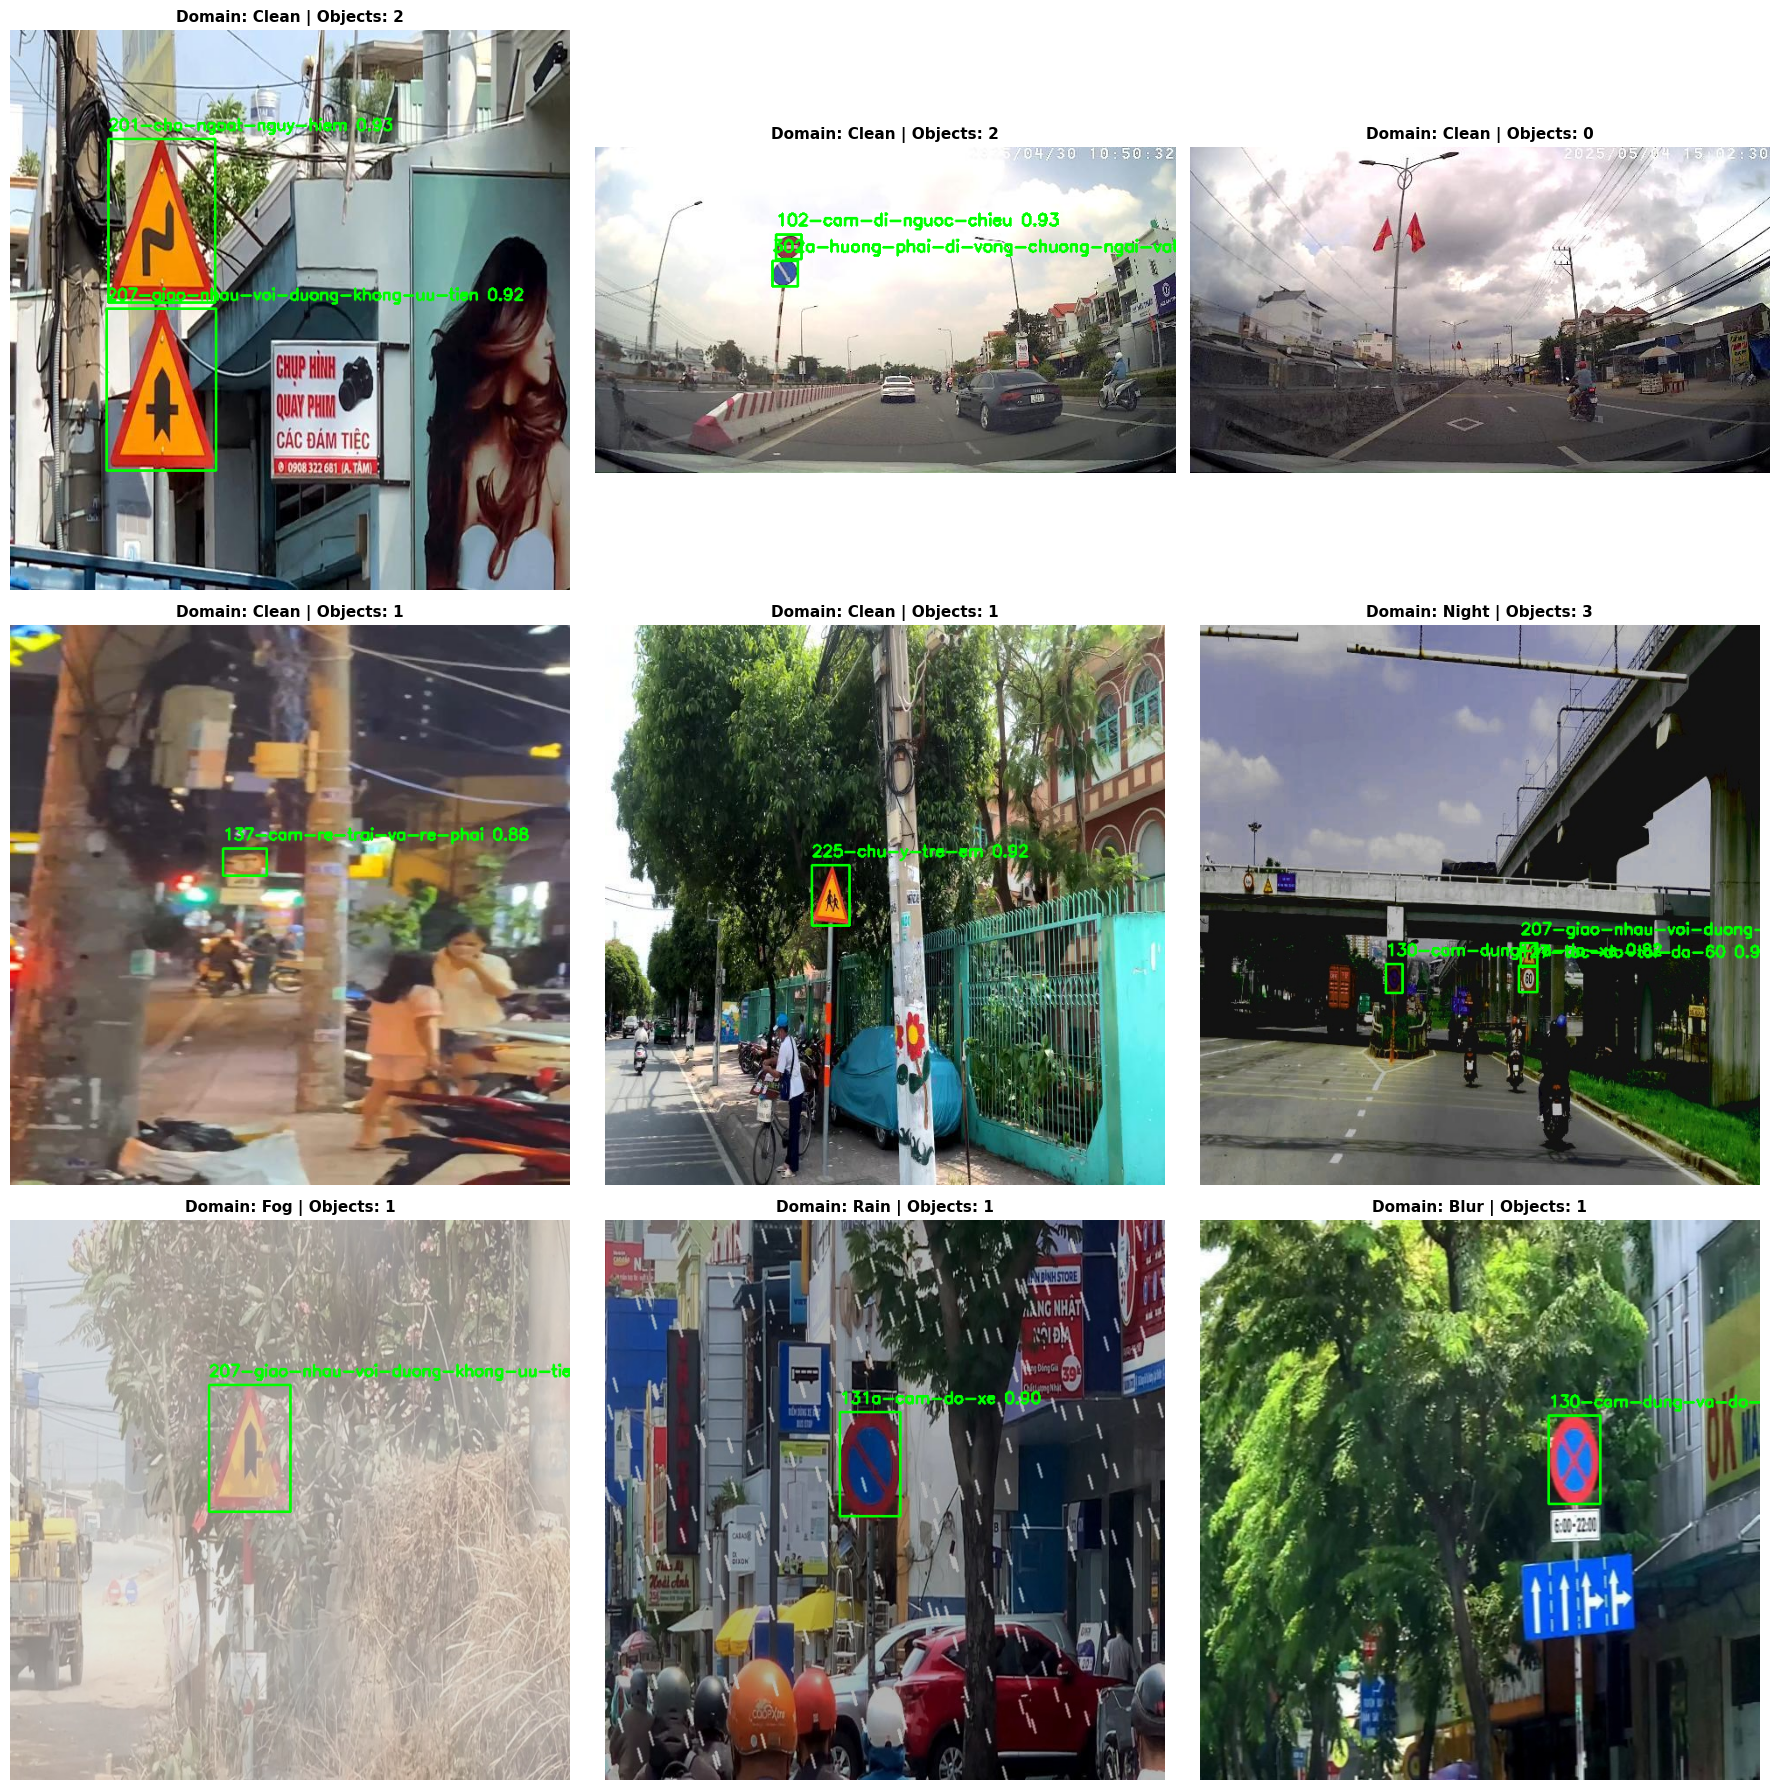

In [7]:
# ==========================================
# 7. Inference Visualization
# ==========================================
print("\n--- Executing Inference Visualization ---")

rng = random.Random(SEED)
pool_clean = list((LOCAL_DATA_DIR / 'test' / 'images').glob('*.*'))
pool_night = list(TEST_EFFECT_DIRS['night']['images'].glob('*.*'))
pool_fog = list(TEST_EFFECT_DIRS['fog']['images'].glob('*.*'))
pool_rain = list(TEST_EFFECT_DIRS['rain']['images'].glob('*.*'))
pool_blur = list(TEST_EFFECT_DIRS['blur']['images'].glob('*.*'))

# Chọn ngẫu nhiên ảnh từ các domain để visualize
target_samples = (
    rng.sample(pool_clean, 5) + 
    rng.sample(pool_night, 1) + 
    rng.sample(pool_fog, 1) + 
    rng.sample(pool_rain, 1) + 
    rng.sample(pool_blur, 1)
)

labels = ["Clean"]*5 + ["Night", "Fog", "Rain", "Blur"]

print("Predicting with model and applying per-class optimal thresholds...")
# CHÚ Ý: Đã đồng bộ imgsz=768
predictions = best_model.predict(target_samples, conf=0.01, imgsz=768, verbose=False)

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for idx, (result, ax, label) in enumerate(zip(predictions, axes, labels)):
    orig_img = result.orig_img.copy()
    img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    
    boxes = result.boxes
    valid_count = 0
    
    if len(boxes) > 0:
        for box in boxes:
            cls_id = int(box.cls[0].item())
            conf_score = box.conf[0].item()
            
            # Lọc bằng Threshold Tối Ưu của từng Class thay vì conf cố định
            if conf_score >= optimal_thresholds.get(cls_id, 0.25):
                valid_count += 1
                
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                cls_name = best_model.names[cls_id]
                
                # Vẽ Bounding Box
                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
                label_text = f"{cls_name} {conf_score:.2f}"
                cv2.putText(img_rgb, label_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                
    print(f"[Domain: {label}] Sample {idx+1}: Filtered Bounding Boxes: {valid_count}")
    
    ax.imshow(img_rgb)
    ax.set_title(f"Domain: {label} | Objects: {valid_count}", fontsize=11, fontweight='bold')
    ax.axis('off')
    
plt.tight_layout()
plt.show()

# 8. ONNX Engine Export
**Purpose:**
* Package the finalized trained model architecture into a serialized `.onnx` graph format.
* Enforce a static spatial resolution framework (768px) to render the model production-ready for Edge Device deployment pipelines.

In [8]:
# ==========================================
# 7. ONNX Engine Export
# ==========================================
export_weights_path = WORKING_DIR / "runs" / "traffic_sign_yolo11n" / "weights" / "best.pt"
export_model = YOLO(export_weights_path)

print("\nExporting trained architecture to serialized ONNX engine format...")
onnx_path = export_model.export(format="onnx", imgsz=768, dynamic=False)

print(f"Pipeline safely concluded. Production runtime model saved at: {onnx_path}")


Exporting trained architecture to serialized ONNX engine format...
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,593,462 parameters, 0 gradients, 9.3 GFLOPs

PyTorch: starting from '/kaggle/working/runs/traffic_sign_yolo11n/weights/best.pt' with input shape (1, 3, 768, 768) BCHW and output shape(s) (1, 62, 12096) (5.3 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 399ms
 Downloaded onnxruntime
Prepared 2 packages in 347ms
Installed 2 packages in 13ms
 + onnxruntime==1.28.0
 + onnxslim==0.1.95

requirements: AutoUpdate success ✅ 1.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting ex